# ML Driven MOF PFAS Adsorbent Discovery

### Set-up

In [2]:
import sys
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For plotting data
import os
#import re
np.random.seed(42)

In [3]:
from sklearn.svm import OneClassSVM, SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVR


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_with_ols(x, y, labels, poly_deg=1, x_label=None, y_label=None, title=None):
    """
    Create a scatter plot of x vs y with an OLS polynomial fit and R-squared.
    
    Parameters
    ----------
    x, y : array-like
        Input feature arrays of equal length.
    poly_deg : int, optional (default=1)
        Polynomial degree for OLS fit (1 = linear, up to 3).
    x_label, y_label : str, optional
        Axis labels.
    title : str, optional
        Plot title.
    """
    if poly_deg < 1 or poly_deg > 3:
        raise ValueError("poly_deg must be 1, 2, or 3")

    x = np.asarray(x)
    y = np.asarray(y)

    # Polynomial OLS fit
    coeffs = np.polyfit(x, y, poly_deg)
    poly = np.poly1d(coeffs)

    # Predictions (sorted for smooth curve)
    x_sorted = np.sort(x)
    y_pred_sorted = poly(x_sorted)
    y_pred = poly(x)

    # R-squared
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - ss_res / ss_tot

    # Plot
    plt.figure()
    # Map labels to colors
    colors = ['red' if l == 0 else 'blue' for l in labels]

    plt.scatter(x, y, c=colors)
#    plt.scatter(x, y)
    plt.plot(x_sorted, y_pred_sorted)
    
    plt.xlabel(x_label if x_label else "X")
    plt.ylabel(y_label if y_label else "Y")
    plt.title(title if title else f"Scatter Plot with Degree-{poly_deg} OLS Fit")

    plt.text(
        0.05, 0.95,
        f"Degree = {poly_deg}\n$R^2 = {r_squared:.3f}$",
        transform=plt.gca().transAxes,
        verticalalignment="top"
    )

    plt.show()

    return r_squared


In [12]:
folder_path = r'../data/'
dfs = {}
file_start = '2.Descriptors-'
file_end = '-TwoClass-v1.csv'

for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith(file_start) and filename.endswith(file_end):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)

        pfas_name = filename.removeprefix(file_start).removesuffix(file_end)
        # pfas_name = filename.replace('Descriptors-', '')
        # pfas_name = pfas_name.replace('.csv', '')
        print(pfas_name)
        dfs[pfas_name] = df

PFOA


In [16]:
file_start = '3.Descriptors-'
file_end = '-EnergyScore.csv'

for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith(file_start) and filename.endswith(file_end):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)

        pfas_name = filename.removeprefix(file_start).removesuffix(file_end)
        # pfas_name = filename.replace('Descriptors-', '')
        # pfas_name = pfas_name.replace('.csv', '')
        print(pfas_name)
        dfs[pfas_name] = df

mixedMOFs


In [17]:
for filename in os.listdir(folder_path):
    #print(filename)
    if filename.startswith('Test') and filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
        mof_name = filename.removeprefix('Test_').removesuffix('.csv')
        print(mof_name)
        dfs[mof_name] = df

coremof
coremof_FSR
coremof_Ion
coremof_NCR
coremof_occupancy


In [18]:
# dfs.keys()
dfs['mixedMOFs']

,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,EnergyScore
0,1,2022[Zr][lvt]3[ASR]1,1.070000,6.93000,9.83000,"2,836.58",0.67000,0.630000,0.379936
1,2,2020[Zn][nan]3[ASR]16,1.210000,11.01000,11.72000,"2,699.02",0.67000,0.550000,0.347601
2,3,2023[La][pts]3[ASR]1,1.210000,7.50000,8.09000,"3,001.63",0.62000,0.510000,0.551153
3,4,2017[Co][nan]3[ASR]5,1.380000,5.76000,7.70000,"2,945.36",0.56000,0.410000,0.228956
4,5,2018[Ce][csq]3[ASR]1,0.560000,17.74000,23.52000,"3,476.89",0.81000,1.440000,0.332494
5,6,ic6b02413_si_002_2_FSR_pacman,0.989594,5.93433,13.64653,2799.06,0.70388,0.711282,0.516035
6,7,ic6b02413_si_002_2_ASR_pacman,0.989594,5.93433,13.64653,2799.06,0.70388,0.711282,0.528492
7,8,ja510525s_si_002_FSR_pacman,1.081860,5.07236,12.04251,2832.29,0.67468,0.623629,0.743175
8,9,ja510525s_si_002_ASR_pacman,1.081860,5.07236,12.04251,2832.29,0.67468,0.623629,0.741055
9,10,jp8b09178_si_007_FSR_pacman,0.487583,28.06898,29.87417,3411.27,0.82990,1.702070,0.310761


### Adsorbent Features

The following adsorbent features are used:

- **Density**: Framework density of the MOF, reflecting how compact or open the porous structure is.
- **PLD (Pore Limiting Diameter)**: Diameter of the largest spherical probe that can pass through the narrowest pore window, indicating if PFAS can **enter** pore.
- **LCD (Largest Cavity Diameter)**: Diameter of the largest spherical cavity within the framework, indicating if the PFAS can **fit** comfortably.
- **GSA (Geometric Surface Area)**: Total internal surface area of the framework accessible to a probe molecule, representing available adsorption surface.
- **Void Fraction**: Fraction of the unit cell volume that is empty space, serving as a measure of porosity.
- **Pore Volume**: Total accessible pore volume per unit mass of the framework, serving as a proxy for adsorption capacity.


# PART-A: Data Filtering

In [19]:
numeric_df = dfs['PFOA'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

,min,max,mean,range
Density,0.175207,2.02273,1.084413,1.847523
PLD,0.621250,28.35169,6.905572,27.730440
LCD,1.497060,34.15409,12.637521,32.657030
GSA,2178.080000,5397.31000,3895.514571,3219.230000
Void_Fraction,0.186605,0.93080,0.591048,0.744195
Pore_Volume,0.099996,5.31257,0.910946,5.212574
Label,0.000000,1.00000,0.714286,1.000000


In [20]:
numeric_df = dfs['PFOA'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

,min,max,mean,range
Density,0.175207,2.02273,1.084413,1.847523
PLD,0.621250,28.35169,6.905572,27.730440
LCD,1.497060,34.15409,12.637521,32.657030
GSA,2178.080000,5397.31000,3895.514571,3219.230000
Void_Fraction,0.186605,0.93080,0.591048,0.744195
Pore_Volume,0.099996,5.31257,0.910946,5.212574
Label,0.000000,1.00000,0.714286,1.000000


In [ ]:
numeric_df = dfs['coremof_FSR'].select_dtypes(include = 'number').drop(columns = 'Serial')
#numeric_df.describe()

summary = pd.DataFrame({
    'min': numeric_df.min(),
    'max': numeric_df.max(),
    'mean': numeric_df.mean(),
    'range': numeric_df.max() - numeric_df.min()
})

summary

We see a few relationships between features:

In [21]:
#Set PFAS type
PFAS = "PFOA" #"coremof"

In [27]:
dfs[PFAS]['Label']

0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    1
31    1
32    0
33    0
34    0
Name: Label, dtype: int64

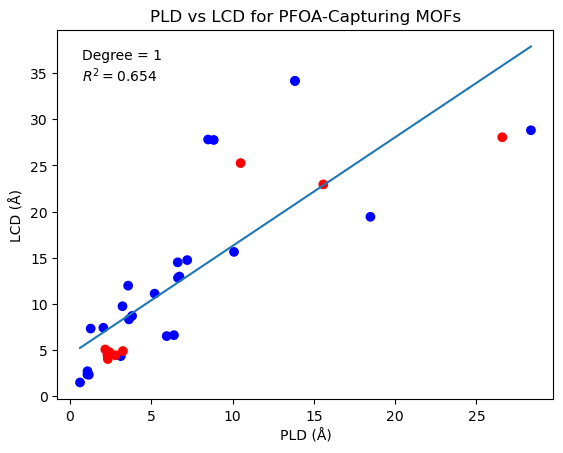

In [35]:
feature1 = "PLD"
feature2 = "LCD"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 1, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")


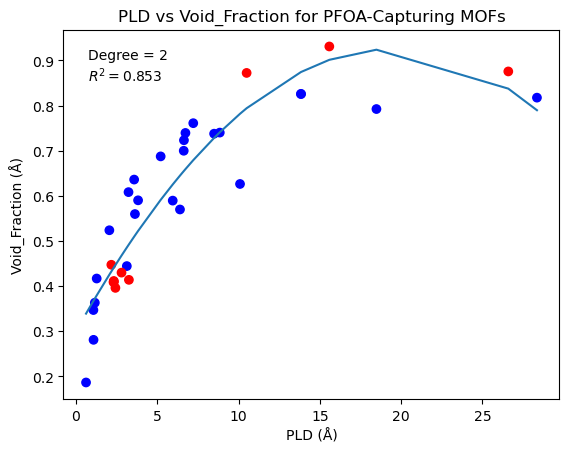

In [37]:
feature1 = "PLD"
feature2 = "Void_Fraction"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")


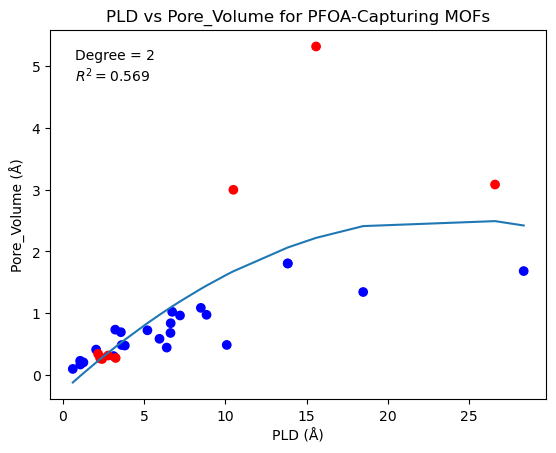

In [39]:
feature1 = "PLD"
feature2 = "Pore_Volume"
r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")

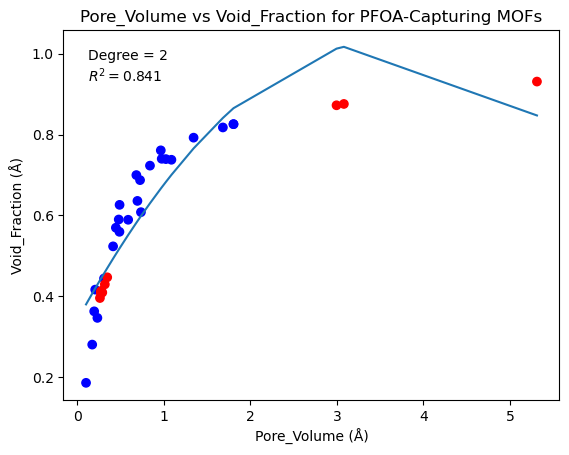

In [41]:
feature1 = "Pore_Volume"
feature2 = "Void_Fraction"

r2 = scatter_with_ols(dfs[PFAS][feature1], dfs[PFAS][feature2], dfs[PFAS]['Label'], 2, x_label=f"{feature1} (Å)", y_label=f"{feature2} (Å)", 
                      title=f"{feature1} vs {feature2} for {PFAS}-Capturing MOFs")

### Key Takeaways




# Two Class SVM

In [67]:
# Core descriptor set
core_features = [
    "PLD",
    "LCD",
    "GSA",
    "Void_Fraction",
    "Pore_Volume",
    # "Density",  # uncomment later for sensitivity analysis
]

# Select PFAS dataset
df = dfs["PFOA"].copy()

# Extract feature matrix
X = df[core_features].values
y = df["Label"]


In [69]:
svc = Pipeline(steps=[("scaler", StandardScaler()),
                      ("svc", SVC(
                          kernel="rbf",
                          C=1.0, #penalisation parameter for classification error
                          gamma="scale",
                          class_weight="balanced" #useful for small imbalanced data
                      ))])

svc.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(class_weight='balanced'))])

In [113]:
svc["svc"].C

1.0

In [77]:
df

,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,Label
0,1,UiO-66,1.234780,3.82175,8.70307,2920.55,0.590055,0.477861,1
1,2,UiO-66-NH2,2.022730,1.27596,7.33306,2383.43,0.416850,0.206083,1
2,3,UiO-66-F4,1.640400,1.08214,2.71819,4812.39,0.281035,0.171321,1
3,4,UiO-67,0.722590,6.73387,12.96894,3474.86,0.739285,1.023110,1
4,5,UiO-67-F2,0.861770,6.64219,12.83075,3058.54,0.723110,0.839102,1
5,6,MOF-808,1.284100,10.09089,15.63835,2178.08,0.626260,0.487702,1
6,7,PCN-999,0.589740,18.48015,19.43968,3429.84,0.792225,1.343360,1
7,8,PCN-1002,1.269210,2.05535,7.42090,3526.25,0.523740,0.412650,1
8,9,DUT-67,1.026710,6.62955,14.50667,2708.09,0.699795,0.681588,1
9,10,NU-1000,0.486040,28.35169,28.81297,3605.15,0.817445,1.681850,1


In [79]:
# Decision function: higher = more confidently inside the region
scores = svc.decision_function(X)

# Binary labels: +1 = inlier, -1 = outlier
labels = svc.predict(X)

df_results = df.copy()
df_results["svm_score"] = scores
df_results["svm_label"] = labels


In [83]:
df_results.sort_values("svm_score", ascending=False)

,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,Label,svm_score,svm_label
4,5,UiO-67-F2,0.861770,6.64219,12.83075,3058.54,0.723110,0.839102,1,1.428156,1
8,9,DUT-67,1.026710,6.62955,14.50667,2708.09,0.699795,0.681588,1,1.421165,1
30,31,2021[Eu][fcu]3[ASR]2,0.789282,7.21484,14.75035,3040.20,0.760900,0.964041,1,1.392622,1
15,16,MIL-100 (Fe),0.759090,8.84616,27.76155,3270.98,0.740035,0.974893,1,1.311893,1
0,1,UiO-66,1.234780,3.82175,8.70307,2920.55,0.590055,0.477861,1,1.271361,1
3,4,UiO-67,0.722590,6.73387,12.96894,3474.86,0.739285,1.023110,1,1.260892,1
12,13,MIL-100(Al),0.678640,8.49713,27.80996,3593.18,0.737620,1.086910,1,1.233725,1
5,6,MOF-808,1.284100,10.09089,15.63835,2178.08,0.626260,0.487702,1,1.120423,1
6,7,PCN-999,0.589740,18.48015,19.43968,3429.84,0.792225,1.343360,1,1.043442,1
1,2,UiO-66-NH2,2.022730,1.27596,7.33306,2383.43,0.416850,0.206083,1,1.000167,1


### Results interpretation:
- only the relative scores are important
- can not iterpret the absoute values (this is not parametric)

### Training with Density

In [ ]:
core_plus_density_features  = core_features + ["Density"]
X_density = df[core_plus_density_features].values

ocsvm_density = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ocsvm", OneClassSVM(
            kernel="rbf",
            nu=nu_hypP,
            gamma="scale"
        ))
    ]
)

ocsvm_density.fit(X_density)

df_results["ocsvm_score_with_density"] = ocsvm_density.decision_function(X_density)


In [ ]:
df_results.sort_values("ocsvm_score")


### Plotting training
- Plot the exact OC-SVM boundary is *impossible* because it lives in 5-6 dimensional (features) space further increased by the kernel induced space.

So the objective becomes to "Visualize how points relate to the OC-SVM decision function in a meaningful 2D projection":

Explanation.

We have two optoins:
  - visualise with first 2 pca, or
  - Decision boundaries were visualized by evaluating the OC-SVM on 2D slices of the scaled descriptor space, constructed by varying selected feature pairs while fixing all remaining descriptors at their mean values.”


In [87]:
scaler = svc.named_steps["scaler"]
svm = svc.named_steps["svc"]
#nu = svc.named_steps["ocsvm"].nu
X_scaled = scaler.transform(X)


In [89]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca1 = X_pca[:, 0]
X_pca2 = X_pca[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)


Explained variance: [0.66803294 0.21362643]


In [91]:
type(df_results['PLD'].to_numpy())
#type(X_feature)

numpy.ndarray

In [93]:
X_scaled

array([[-0.45945505, -0.40255053, -1.29554504, -0.00523966, -0.41623386],
       [-0.83874937, -0.5427221 , -2.00927677, -0.91917255, -0.67743727],
       [-0.86762639, -1.01488916,  1.21835547, -1.6358135 , -0.71084672],
       [-0.02558164,  0.03390885, -0.55897102,  0.78218683,  0.10780009],
       [-0.03924094,  0.01977004, -1.11218221,  0.69683788, -0.06904835],
       [ 0.4745769 ,  0.30702759, -2.28214841,  0.18579951, -0.40677576],
       [ 1.72448309,  0.69595789, -0.61879416,  1.06152984,  0.41558951],
       [-0.72262895, -0.53373482, -0.49068335, -0.35515715, -0.47890757],
       [-0.04112416,  0.19124057, -1.57786453,  0.57381403, -0.22043365],
       [ 3.19523247,  1.65497923, -0.38584005,  1.19460561,  0.74090923],
       [-0.14200153, -0.62596909,  0.12669619, -0.0087486 , -0.31131827],
       [-0.48816669, -0.44070352, -0.4200304 , -0.16564819, -0.40820586],
       [ 0.23712444,  1.55235699, -0.40174594,  0.7734013 ,  0.16911771],
       [ 1.03325827,  2.20145203, -0.1

In [95]:
#Select Plot space
plot_space = 1 # plot_space: 1 --> PCA plo; 2--> original features
feat_x = 0  # e.g. PLD
feat_y = 1  # e.g. LCD

if plot_space == 1:
    X_feature = X_pca1
    Y_feature = X_pca2
else: 
    X_feature = X_scaled[:, feat_x]
    Y_feature = X_scaled[:, feat_y]
    


In [97]:
#Build a grid in selected space

x_min, x_max = X_feature.min() - 1, X_feature.max() + 1
y_min, y_max = Y_feature.min() - 1, Y_feature.max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

#grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_2d = np.c_[xx.ravel(), yy.ravel()]

In [99]:
# Back to scaled feature space
#grid_scaled = pca.inverse_transform(grid__2d)
# Back to scaled feature space (version that allows to plot original features)
if plot_space == 1:
    grid_scaled = pca.inverse_transform(grid_2d)
else:
    # Start from mean of scaled data: 
    grid_scaled = np.tile(X_scaled.mean(axis=0), (grid_2d.shape[0], 1)) 

    # Insert grid values into the selected feature dimensions
    grid_scaled[:, feat_x] = grid_2d[:, 0]
    grid_scaled[:, feat_y] = grid_2d[:, 1]

# Evaluate OC-SVM decision function
Z = svm.decision_function(grid_scaled)
Z = Z.reshape(xx.shape)


### Plot Training

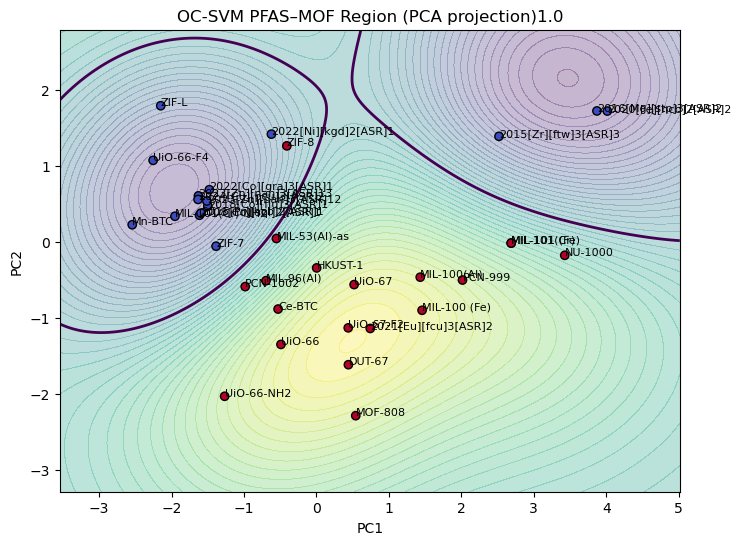

In [117]:
#import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# Plot points
labels = svc.predict(X)
plt.scatter(
    X_feature, Y_feature,
    c=labels, cmap="coolwarm", edgecolors="k"
)

# Annotate MOFs
for i, name in enumerate(df["Name"]):
    plt.text(X_feature[i], Y_feature[i], name, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"OC-SVM PFAS–MOF Region (PCA projection){svc["svc"].C}")

plt.savefig(rf"..\Notebooks\SVM-Region-C{svc["svc"].C}.png", 
            format='png', 
            bbox_inches='tight', 
            transparent=True,
            pad_inches=0)
plt.show()


### Some more thoughts:

- Material Identity discovery vs material property prediciton
- i.e. we are answering "Does this look like the kind of MOFs that work"? Not anwering "How well will this MOF work".

# Regression Model

In [21]:
# Core descriptor set
core_features = [
    "PLD",
    "LCD",
    "GSA",
    "Void_Fraction",
    "Pore_Volume",
    # "Density",  # uncomment later for sensitivity analysis
]

# Select PFAS dataset
df_svr = dfs["mixedMOFs"].copy()

# Extract feature matrix
X_svr = df_svr[core_features].values
y_svr = df_svr["EnergyScore"]

In [22]:
X_svr

X_svr = np.char.replace(X_svr.astype(str), ',', '').astype(float)

In [23]:
from sklearn.svm import SVR

svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
])

svr.fit(X_svr, y_svr)

Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR())])

In [24]:
scores = svr.predict(X_svr)

df_results = df_svr.copy()
df_results["svr_score"] = scores

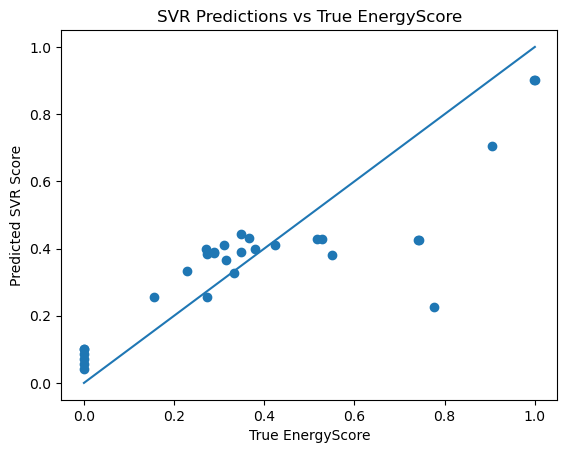

In [25]:
# Scatter plot
plt.figure()
plt.scatter(df_results["EnergyScore"], df_results["svr_score"])

# Labels
plt.xlabel("True EnergyScore")
plt.ylabel("Predicted SVR Score")
plt.title("SVR Predictions vs True EnergyScore")

# Optional: add y=x reference line
min_val = min(df_results["EnergyScore"].min(), df_results["svr_score"].min())
max_val = max(df_results["EnergyScore"].max(), df_results["svr_score"].max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.savefig("SVR.png", dpi=300, transparent=False, bbox_inches='tight')

plt.show()

In [15]:
df_results

,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,EnergyScore,svr_score
0,1,2022[Zr][lvt]3[ASR]1,1.070000,6.93000,9.83000,"2,836.58",0.67000,0.630000,0.379936,0.398546
1,2,2020[Zn][nan]3[ASR]16,1.210000,11.01000,11.72000,"2,699.02",0.67000,0.550000,0.347601,0.443871
2,3,2023[La][pts]3[ASR]1,1.210000,7.50000,8.09000,"3,001.63",0.62000,0.510000,0.551153,0.380829
3,4,2017[Co][nan]3[ASR]5,1.380000,5.76000,7.70000,"2,945.36",0.56000,0.410000,0.228956,0.332160
4,5,2018[Ce][csq]3[ASR]1,0.560000,17.74000,23.52000,"3,476.89",0.81000,1.440000,0.332494,0.328129
5,6,ic6b02413_si_002_2_FSR_pacman,0.989594,5.93433,13.64653,2799.06,0.70388,0.711282,0.516035,0.428454
6,7,ic6b02413_si_002_2_ASR_pacman,0.989594,5.93433,13.64653,2799.06,0.70388,0.711282,0.528492,0.428454
7,8,ja510525s_si_002_FSR_pacman,1.081860,5.07236,12.04251,2832.29,0.67468,0.623629,0.743175,0.424146
8,9,ja510525s_si_002_ASR_pacman,1.081860,5.07236,12.04251,2832.29,0.67468,0.623629,0.741055,0.424146
9,10,jp8b09178_si_007_FSR_pacman,0.487583,28.06898,29.87417,3411.27,0.82990,1.702070,0.310761,0.410741


In [17]:
dfs['coremof']

,Serial,Name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,UnitCell_MW_g_mol
0,1,0000[Co][nan]2[ASR]1,1.072480,3.39533,5.36890,4709.77,0.5046,0.470498,1351.242
1,2,0000[Co][nan]3[ASR]10,1.179070,4.88500,6.95063,4670.75,0.4580,0.388442,2026.863
2,3,0000[Co][nan]3[ASR]11,1.174010,4.89728,7.26419,4675.95,0.4615,0.393096,4053.726
3,4,0000[Co][nan]3[ASR]4,1.155890,5.06226,6.56429,4757.67,0.4539,0.392685,2020.935
4,5,0000[Co][nan]3[ASR]5,1.190440,4.96028,6.53077,4661.17,0.4483,0.376582,2032.911
...,...,...,...,...,...,...,...,...,...
1367,1368,2024[Zn][sra]3[ASR]1,1.005420,4.83588,7.28441,5071.48,0.5600,0.556982,4103.000
1368,1369,2024[Zn][srs]3[ASR]1,1.134090,3.91591,4.46614,3705.98,0.6375,0.562127,737.948
1369,1370,2024[Zn][srs]3[ASR]2,1.138620,3.90119,4.44679,3689.57,0.6299,0.553215,737.948
1370,1371,2024[Zn][ths]3[ASR]1,1.238990,3.55129,4.49807,4761.47,0.4807,0.387977,906.406


In [18]:
# Select new dataset
df_new = dfs["coremof"].copy()

# Ensure required features exist
missing = [col for col in core_features if col not in df_new.columns]
if missing:
    raise ValueError(f"Missing required features in coremof dataset: {missing}")

# Extract features using the SAME core_features
X_new = df_new[core_features].values

# Predict using trained pipeline (scaling is automatically applied)
new_scores = svr.predict(X_new)

# Store results
df_new_results = df_new.copy()
df_new_results["svr_score"] = new_scores

# Save to CSV
df_new_results.to_csv("coremof_svr_scores.csv", index=False)

## Regression Plot

In [ ]:
scaler = svr.named_steps["scaler"]
svm = svc.named_steps["svc"]
#nu = svc.named_steps["ocsvm"].nu
X_scaled = scaler.transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca1 = X_pca[:, 0]
X_pca2 = X_pca[:, 1]

print("Explained variance:", pca.explained_variance_ratio_)





# Testing

#### Test: Inference (SVM)


- *Output Score Intepretation*: A signed geometric margin measuring how strongly a structure belongs to the learned PFAS-compatible descriptor region (OCSVM).
$$
f(x) = \sum_{i=1}^{n} \alpha_i \, K(x_i, x\prime) - \rho
$$
By contrast the SVM classifier seeks to maximise the margin between two regions.
$$
f(x)=\sum_{i=1}^{n} \alpha_i y_i K(x_i,x) + b
$$
where:
$x_i$ are known PFAS MOF descriptors, (one per training sample - not feature - nice feature, see 'Representer Theorem').
$x\prime$ is the candidate MOF descriptor to be evaluated.
 
- *Parameter Intepretation*: An upper bound on the fraction of training points allowed to be outside (small 'nu' --> model tries to include all point in training --> large permissive boundary).
- Standardisation centres all observation around mean with a 'few' std devs of data on either side. While this does not mean distance between two points is zero, it does imply "small" distance scores for points within the learned region. 

- Note, the kernel used is the RBF kernel that allows non-linear regions:
$$
K(x, x\prime) = \exp\left(-\gamma \|x - x\prime\|^2\right)
$$


dfs.keys():
dict_keys(['PFOA', 'PFOS', 'coremof', 'coremof_FSR', 'coremof_Ion', 'coremof_NCR', 'coremof_occupancy'])


In [233]:
#NEW
test_set = "coremof_NCR"
X_coremof = dfs[test_set][core_features].values

scores_core = svc.decision_function(X_coremof)
labels_core = svc.predict(X_coremof)

In [234]:
#NEW
dfs[test_set]["score_svm"] = scores_core
dfs[test_set]["label_svm"] = labels_core
dfs[test_set]

,Serial,name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,UnitCell_MW_g_mol,score_svm,label_svm
0,1,10853_2020_5211_MOESM2_ESM_ASR_pacman,2.169740,3.05972,4.66272,3049.65,0.35642,0.164269,1363.282,0.446043,1
1,2,10853_2020_5211_MOESM2_ESM_FSR_pacman,2.197130,3.01004,3.93796,3080.84,0.34412,0.156622,1395.280,0.371509,1
2,3,10876_2019_1683_MOESM2_ESM_1_ASR_pacman,1.356210,2.58732,4.32227,3908.72,0.47254,0.348426,1356.688,-0.440319,0
3,4,10876_2019_1683_MOESM2_ESM_1_FSR_pacman,1.356210,2.58732,4.32227,3908.72,0.47254,0.348426,1356.688,-0.440319,0
4,5,10876_2019_1683_MOESM2_ESM_2_ASR_pacman,1.418170,3.52505,4.11240,4046.09,0.42196,0.297538,2677.384,-0.741892,0
...,...,...,...,...,...,...,...,...,...,...,...
3687,3688,se7b00236_si_002_FSR_pacman,0.656184,7.48036,19.33332,3538.77,0.75588,1.151930,7230.960,1.241724,1
3688,3689,tz9b00021_si_007_ASR_pacman,0.522934,11.58302,13.57403,4097.85,0.79032,1.511320,2555.702,0.652632,1
3689,3690,tz9b00021_si_007_FSR_pacman,0.522934,11.58302,13.57403,4097.85,0.79032,1.511320,2555.702,0.652632,1
3690,3691,tz9b00468_si_001_ASR_pacman,0.745844,9.09617,14.19833,3724.88,0.73880,0.990555,11216.040,1.159022,1


In [235]:
results_sorted = dfs[test_set].sort_values("score_svm", ascending=False)
results_sorted

,Serial,name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,UnitCell_MW_g_mol,score_svm,label_svm
2772,2773,ic6b02413_si_002_2_FSR_pacman,0.989594,5.93433,13.64653,2799.06,0.70388,0.711282,9956.496,1.436422,1
2771,2772,ic6b02413_si_002_2_ASR_pacman,0.989594,5.93433,13.64653,2799.06,0.70388,0.711282,9956.496,1.436422,1
2958,2959,ja510525s_si_002_FSR_pacman,1.081860,5.07236,12.04251,2832.29,0.67468,0.623629,3084.225,1.435853,1
2957,2958,ja510525s_si_002_ASR_pacman,1.081860,5.07236,12.04251,2832.29,0.67468,0.623629,3084.225,1.435853,1
2146,2147,d1dt02515e2_1_FSR_pacman,1.132110,6.42748,9.60663,2838.88,0.69104,0.610402,2453.572,1.431632,1
...,...,...,...,...,...,...,...,...,...,...,...
1806,1807,d0ce00262c2_3_FSR_pacman,1.400660,2.63845,3.99565,4622.86,0.39650,0.283081,3810.832,-1.116331,0
1805,1806,d0ce00262c2_3_ASR_pacman,1.400660,2.63845,3.99565,4622.86,0.39650,0.283081,3810.832,-1.116331,0
821,822,c7dt02800h2_3_ion_pacman,1.518550,1.30531,2.85036,4680.54,0.37134,0.244535,8595.600,-1.126573,0
579,580,c6ce00407e7_ASR_pacman,0.207465,15.95479,33.68342,4888.62,0.90886,4.380800,10846.176,-1.155682,0


In [236]:
output_folder = r'..\results\SVM'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
file_path = os.path.join(output_folder, f"{test_set}_SVM-results_C{svc["svc"].C}.csv")

results_sorted.to_csv(file_path, index=False)

#### Testing: Inference (SVR)

In [96]:
# coremof
# coremof_FSR
# coremof_Ion
# coremof_NCR
# coremof_occupancy

test_set = "coremof_occupancy"
X_coremof = dfs[test_set][core_features].values

scores_core = svr.predict(X_coremof)

In [98]:
dfs[test_set]["score_svr"] = scores_core
dfs[test_set]

,Serial,name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,UnitCell_MW_g_mol,score_svr
0,1,am0c01198_si_002_FSR_pacman,1.132090,4.46884,5.99272,4985.80,0.46792,0.413323,3036.072,0.200905
1,2,am0c02121_si_002_1_ion_pacman,1.588230,4.40283,5.38384,3600.39,0.44992,0.283284,1108.880,0.152701
2,3,am0c02121_si_002_2_ion_pacman,1.610600,3.77609,5.08345,3608.82,0.44220,0.274556,1564.772,0.130876
3,4,am0c02121_si_002_3_ion_pacman,1.658380,3.01201,4.55854,3551.15,0.43438,0.261931,1108.880,0.106180
4,5,am0c02121_si_002_4_ion_pacman,1.616810,4.18293,5.25094,3555.93,0.45040,0.278573,1585.655,0.148742
...,...,...,...,...,...,...,...,...,...,...
304,305,sc8b04783_si_002_FSR_pacman,0.603307,5.40588,11.90372,4248.26,0.75908,1.258200,5788.494,0.382076
305,306,sc8b04783_si_003_FSR_pacman,0.623771,5.38751,11.75758,4170.59,0.75544,1.211090,6004.374,0.381831
306,307,sc8b04783_si_005_ASR_pacman,0.658979,5.46550,11.22564,4547.97,0.72672,1.102800,6473.490,0.393156
307,308,sc8b04783_si_005_FSR_pacman,0.658979,5.46550,11.22564,4547.97,0.72672,1.102800,6473.490,0.393156


In [100]:
results_sorted = dfs[test_set].sort_values("score_svr", ascending=False)
results_sorted

,Serial,name,Density,PLD,LCD,GSA,Void_Fraction,Pore_Volume,UnitCell_MW_g_mol,score_svr
218,219,el9b00088_si_004_FSR_pacman,1.045530,17.57553,19.17744,3705.47,0.62762,0.600291,11566.314,0.491727
308,309,sc8b05524_si_002_ASR_pacman,0.550707,24.42917,29.55575,3155.22,0.81018,1.471160,7339.260,0.490193
217,218,el9b00088_si_004_ASR_pacman,0.902144,17.57553,19.17744,3273.63,0.70620,0.782802,9980.118,0.478829
263,264,ja7b08347_si_005_FSR_pacman,0.346669,8.66056,28.66527,4222.04,0.86894,2.506540,24358.880,0.463573
262,263,ja7b08347_si_005_ASR_pacman,0.346669,8.66056,28.66527,4222.04,0.86894,2.506540,24358.880,0.463573
...,...,...,...,...,...,...,...,...,...,...
151,152,cg900505v_si_004_ASR_pacman,2.331430,2.79211,4.53527,3290.55,0.34284,0.147051,2805.580,0.061053
149,150,cg900505v_si_002_ASR_pacman,2.360300,2.81593,4.48290,3281.60,0.33650,0.142567,2805.580,0.059745
150,151,cg900505v_si_002_FSR_pacman,2.360300,2.81593,4.48290,3281.60,0.33650,0.142567,2805.580,0.059745
172,173,d0ce01101k2_ASR_pacman,1.888020,2.59848,3.55728,3411.82,0.35104,0.185930,2192.976,0.039949


In [102]:
output_folder = r'..\results\SVR'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)
file_path = os.path.join(output_folder, f"{test_set}_SVR-results_C{svr["svr"].C}.csv")

results_sorted.to_csv(file_path, index=False)

#### Testing: comparing models
- Important ..

#### Testing: Plotting
- Important to remember not to refit PCA on coremof

In [239]:
# Use the SAME scaler from pipeline
scaler = svc.named_steps["scaler"]
X_test_core = dfs[test_set][core_features].values
X_test_scaled = scaler.transform(X_test_core)

# Project into PCA space
X_test_pca = pca.transform(X_test_scaled)
    
X_test_pca1 = X_test_pca[:, 0]
X_test_pca2 = X_test_pca[:, 1]

In [240]:
# # Get labels for coremof
# labels_core = ocsvm.predict(X_coremof_core)

# # Overlay coremof points
# plt.scatter(
#     X_coremof_pca1,
#     X_coremof_pca2,
#     c=labels_core,
#     cmap="coolwarm",
#     marker="x",
#     s=40,
#     alpha=0.7
# )


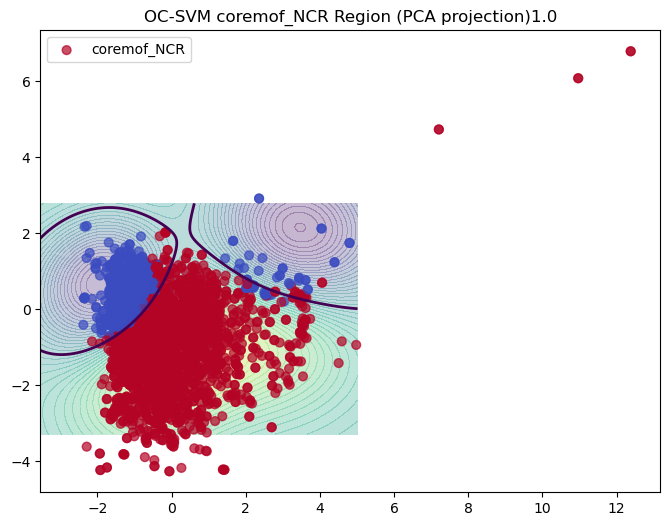

In [241]:
# Training data
plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# plt.scatter(X_feature, Y_feature,
#             c=labels,
#             cmap="coolwarm",
#             edgecolors="k",
#             s=80,
#             label="Training MOFs")

# Coremof data
plt.scatter(X_test_pca1,
            X_test_pca2,
            c=labels_core,
            cmap="coolwarm",
            marker="o",
            s=40,
            alpha=0.7,
            label=test_set)

plt.legend()
plt.title(f"OC-SVM {test_set} Region (PCA projection){svc["svc"].C}")
plt.savefig(rf"..\Notebooks\SVM-Test-{test_set}-C{svc["svc"].C}.png", 
            format='png', 
            bbox_inches='tight', 
            transparent=True,
            pad_inches=0)
plt.show()


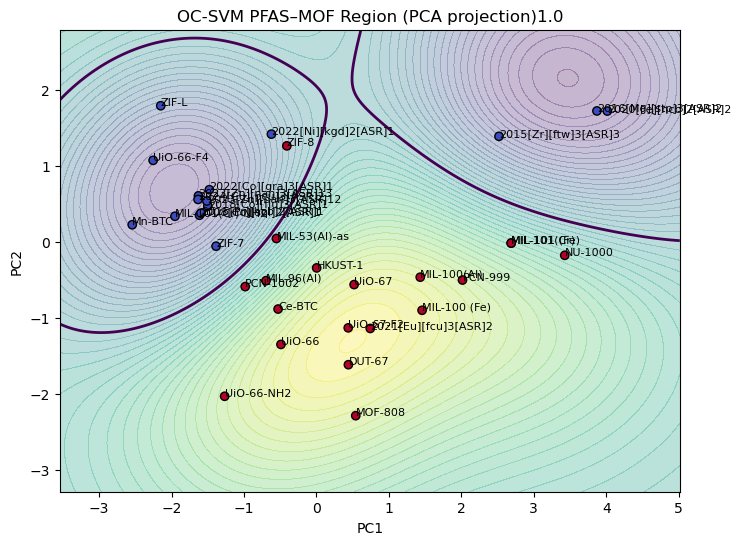

In [242]:
plt.figure(figsize=(8, 6))

# Decision boundary (score = 0)
plt.contour(xx, yy, Z, levels=[0], linewidths=2)

# Filled contours (optional)
plt.contourf(xx, yy, Z, levels=50, alpha=0.3)

# Plot points
labels = svc.predict(X)
plt.scatter(
    X_feature, Y_feature,
    c=labels, cmap="coolwarm", edgecolors="k"
)

# Annotate MOFs
for i, name in enumerate(df["Name"]):
    plt.text(X_feature[i], Y_feature[i], name, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"OC-SVM PFAS–MOF Region (PCA projection){svc["svc"].C}")

# plt.savefig(rf"..\Notebooks\OCSVM-Region-C{svc["svc"].C}.png", 
#             format='png', 
#             bbox_inches='tight', 
#             transparent=True,
#             pad_inches=0)
plt.show()

In [243]:
result_df_15

NameError: name 'result_df_15' is not defined